In [1]:
#download needed libraries,
%pip install kagglehub numpy pandas scikit-learn matplotlib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# try to get the file or crash out if missing
try:
    df = pd.read_csv('.\DATA\Airbnb_Open_Data.csv')
    print("row count:", len(df))
except:
    print("fix path to Airbnb_Open_Data.csv")

# lower case cols and add underscores
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# clean up the messy price columns 
for c in ['price', 'service_fee']:
    if c in df.columns:
        df[c] = df[c].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip()
        df[c] = pd.to_numeric(df[c], errors='coerce')

print("\ncols ready:")
print(df[['price', 'service_fee']].dtypes)
display(df.head())

<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:7: SyntaxWarning: invalid escape sequence '\D'
C:\Users\denis.aosa\AppData\Local\Temp\ipykernel_37676\4289972517.py:7: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('.\DATA\Airbnb_Open_Data.csv')


C:\Users\denis.aosa\AppData\Local\Temp\ipykernel_37676\4289972517.py:7: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('.\DATA\Airbnb_Open_Data.csv')


row count: 102599

cols ready:
price          float64
service_fee    float64
dtype: object


,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,...,service_fee,minimum_nights,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


nulls before:
 license                           102597
house_rules                        52131
last_review                        15893
reviews_per_month                  15879
country                              532
availability_365                     448
minimum_nights                       409
host_name                            406
review_rate_number                   326
calculated_host_listings_count       319
host_identity_verified               289
service_fee                          273
name                                 250
price                                247
construction_year                    214
number_of_reviews                    183
country_code                         131
instant_bookable                     105
cancellation_policy                   76
neighbourhood_group                   29
neighbourhood                         16
long                                   8
lat                                    8
dtype: int64



nulls left:
price                  0
service_fee            0
construction_year      0
neighbourhood_group    0
dtype: int64


C:\Users\denis.aosa\AppData\Local\Temp\ipykernel_37676\1309407565.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include=['object']).columns


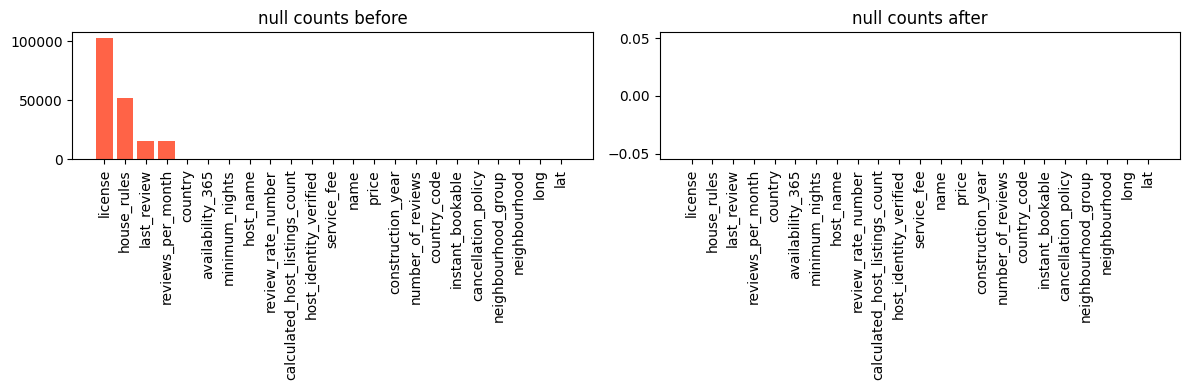

,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,...,service_fee,minimum_nights,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,Unknown
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,Unknown
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,Unknown,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,Unknown,0.74,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",Unknown
3,1002755,Unknown,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,Unknown,Unknown
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",Unknown


In [3]:
# nulls before any filling
nulls_before = df.isnull().sum()
nulls_before = nulls_before[nulls_before > 0].sort_values(ascending=False)
print("nulls before:\n", nulls_before)

# 1. fix neighborhood typos and blanks
if 'neighbourhood_group' in df.columns:
    df['neighbourhood_group'] = df['neighbourhood_group'].fillna('Unknown').replace({'brookln': 'Brooklyn', 'manhatan': 'Manhattan'})

# fill policy and room types with mode
df['cancellation_policy'] = df['cancellation_policy'].fillna(df['cancellation_policy'].mode()[0])
df['room_type'] = df['room_type'].fillna(df['room_type'].mode()[0])

# 2. replace all numerical nan types with their column median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 3. fill any leftover text columns with 'Unknown'
text_cols = df.select_dtypes(include=['object']).columns
df[text_cols] = df[text_cols].fillna('Unknown')

# nulls after filling (reindexed to match the before chart)
nulls_after = df.isnull().sum().reindex(nulls_before.index).fillna(0)

print("\nnulls left:")
print(df[['price', 'service_fee', 'construction_year', 'neighbourhood_group']].isnull().sum())

# before/after bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(nulls_before.index, nulls_before.values, color='tomato')
axes[0].set_title("null counts before")
axes[0].tick_params(axis='x', rotation=90)

axes[1].bar(nulls_before.index, nulls_after.values, color='seagreen')
axes[1].set_title("null counts after")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

display(df.head())

dropped 0 zero-price rows
count    102599.000000
mean          0.200246
std           0.018247
min           0.016026
25%           0.199605
50%           0.200000
75%           0.200391
max           2.500000
Name: fee_to_price_ratio, dtype: float64


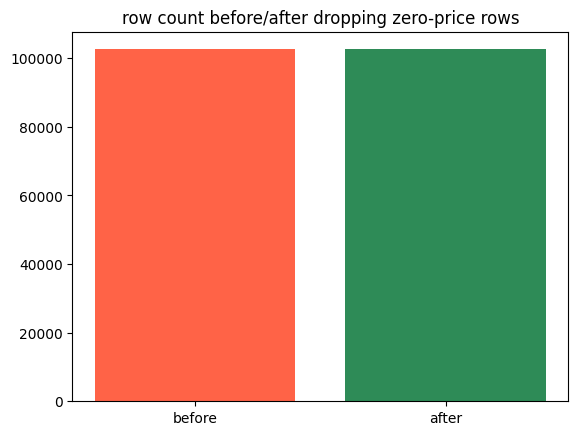

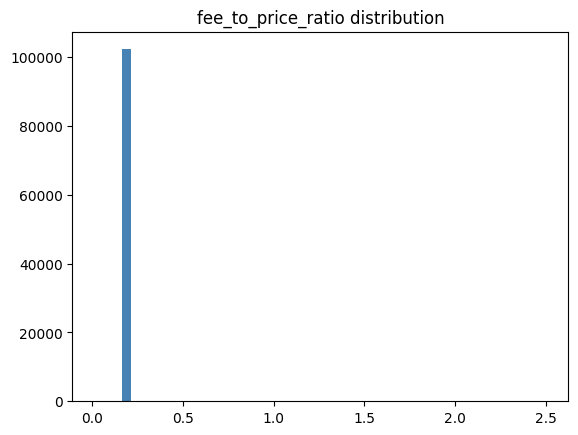

,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,...,minimum_nights,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365,house_rules,license,fee_to_price_ratio
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,Unknown,0.199793
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,Unknown,0.197183
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,Unknown,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,3.0,0.0,Unknown,0.74,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",Unknown,0.200000
3,1002755,Unknown,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,Unknown,Unknown,0.201087
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",Unknown,0.200980


In [4]:
#remove rows with negative or zer0 values
rows_before = len(df)

bad_rows = df[df['price'] <= 0].index
df = df.drop(index=bad_rows).reset_index(drop=True)
rows_after = len(df)
print(f"dropped {len(bad_rows)} zero-price rows")

#fee ratio
df['fee_to_price_ratio'] = df['service_fee'] / df['price']
print(df['fee_to_price_ratio'].describe())

# before/after row count
plt.bar(['before', 'after'], [rows_before, rows_after], color=['tomato', 'seagreen'])
plt.title("row count before/after dropping zero-price rows")
plt.show()

# fee_to_price_ratio distribution (new engineered feature)
plt.hist(df['fee_to_price_ratio'], bins=50, color='steelblue')
plt.title("fee_to_price_ratio distribution")
plt.show()

display(df.head())

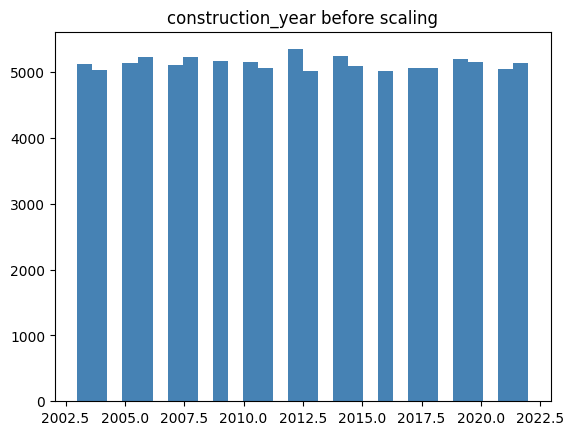

scale check:
min: 0.0 max: 1.0


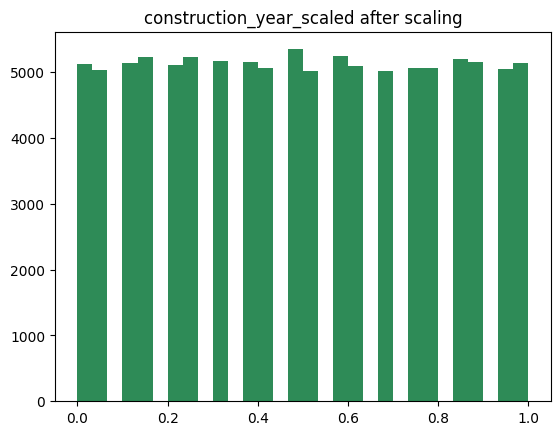

,id,name,host_id,host_identity_verified,host_name,neighbourhood_group,neighbourhood,lat,long,country,...,number_of_reviews,last_review,reviews_per_month,review_rate_number,calculated_host_listings_count,availability_365,house_rules,license,fee_to_price_ratio,construction_year_scaled
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,Unknown,0.199793,0.894737
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,Unknown,0.197183,0.210526
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,Unknown,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,0.0,Unknown,0.74,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",Unknown,0.200000,0.105263
3,1002755,Unknown,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,270.0,7/5/2019,4.64,4.0,1.0,322.0,Unknown,Unknown,0.201087,0.105263
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",Unknown,0.200980,0.315789


In [5]:
# before plot - raw year range
plt.hist(df['construction_year'], bins=30, color='steelblue')
plt.title("construction_year before scaling")
plt.show()

# custom min max scaling for year built
y_min = df['construction_year'].min()
y_max = df['construction_year'].max()

if (y_max - y_min) != 0:
    df['construction_year_scaled'] = (df['construction_year'] - y_min) / (y_max - y_min)
else:
    df['construction_year_scaled'] = 0.0

print("scale check:")
print("min:", df['construction_year_scaled'].min(), "max:", df['construction_year_scaled'].max())

# after plot - same shape, just rescaled to [0,1]
plt.hist(df['construction_year_scaled'], bins=30, color='seagreen')
plt.title("construction_year_scaled after scaling")
plt.show()

display(df.head())

skew before:

 3.843154418323127


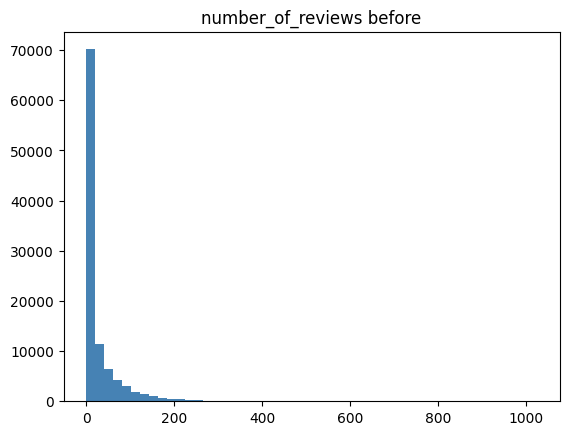

skew after: 0.22683165557436996


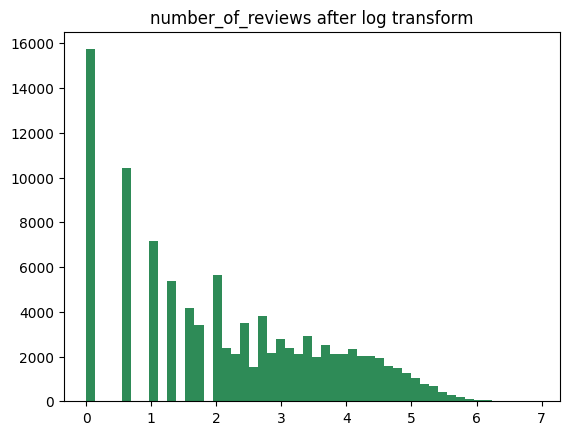

,number_of_reviews,reviews_log
0,9.0,2.302585
1,45.0,3.828641
2,0.0,0.000000
3,270.0,5.602119
4,9.0,2.302585


In [6]:
# print original number_of_reviews skew
print("skew before:", df['number_of_reviews'].skew())

# before plot
plt.hist(df['number_of_reviews'], bins=50, color='steelblue')
plt.title("number_of_reviews before")
plt.show()

# log transform to fix the skew (this actually reshapes the distribution)
df['reviews_log'] = np.log1p(df['number_of_reviews'])

print("skew after:", df['reviews_log'].skew())

# after plot
plt.hist(df['reviews_log'], bins=50, color='seagreen')
plt.title("number_of_reviews after log transform")
plt.show()

display(df[['number_of_reviews', 'reviews_log']].head())

In [7]:
# Use pd.get_dummies() targeting the room_type and cancellation_policy columns.
# Pass drop_first=True to eliminate redundant tracking data and prevent multi-collinearity (the dummy variable trap).
# Specify dtype=int to force the output to display as numbers (1/0) instead of Booleans (True/False).
df = pd.get_dummies(df, columns=['room_type', 'cancellation_policy'], drop_first=True, dtype=int)


In [8]:
from sklearn.utils import resample

# Isolate the dataset into two distinct dataframes based on class membership (True vs False)
df_true = df[df['instant_bookable'] == True]
df_false = df[df['instant_bookable'] == False]

# Identify majority and minority dataframes
if len(df_true) < len(df_false):
    df_minority = df_true
    df_majority = df_false
else:
    df_minority = df_false
    df_majority = df_true

# Downsample majority class observations without replacement
df_majority_downsampled = resample(
    df_majority,
    replace=False,
    n_samples=len(df_minority),
    random_state=42
)

# Recombine the dataframes using pd.concat() and invoke .reset_index(drop=True)
df = pd.concat([df_minority, df_majority_downsampled]).reset_index(drop=True)


In [9]:
# Convert the neighbourhood_group column type to a categorical type using .astype('category')
df['neighbourhood_group'] = df['neighbourhood_group'].astype('category')

# Extract the underlying numerical mappings by calling the .cat.codes attribute, and write them to a new column named neighbourhood_group_code
df['neighbourhood_group_code'] = df['neighbourhood_group'].cat.codes

# Also convert host_identity_verified to category codes to make it numeric
if 'host_identity_verified' in df.columns:
    df['host_identity_verified'] = df['host_identity_verified'].astype('category').cat.codes


In [10]:
import os

# Consolidate non-predictive metadata names into an exclusion list (id, name, host_id, host_name, etc.)
exclude_cols = ['id', 'name', 'host_id', 'host_name', 'country', 'country_code', 'license', 'house_rules', 'last_review', 'neighbourhood', 'neighbourhood_group']

# Drop the target features using df.drop(columns=...), filtering for features that are active in the current dataframe state
cols_to_drop = [c for c in exclude_cols if c in df.columns]
df = df.drop(columns=cols_to_drop)

# Export the resulting dataframe via .to_csv() into the working folder as \DATA\Airbnb_Cleaned_Data.csv with index=False.
output_dir = os.path.join('.', 'DATA')
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, 'Airbnb_Cleaned_Data.csv')
df.to_csv(output_path, index=False)


In [11]:
from sklearn.model_selection import train_test_split

# Separate your input features (X) from your target variable (y) by dropping the target column from your input data
X = df.drop(columns=['instant_bookable'])
y = df['instant_bookable'].astype(int)

# Use Scikit-Learn's train_test_split to divide the dataset into 70% for training and 30% for testing by setting test_size=0.3
# Set random_state=42 to ensure the split is perfectly reproducible every time a team member runs the notebook
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, y_test shape: {y_test.shape}")


X_train shape: (71428, 21), X_test shape: (30612, 21)
y_train shape: (71428,), y_test shape: (30612,)


Once you implement the code for a cell, mark an "X" in the checkbox [X] and add your name next to it.

[X] Task 1 Done By: [ Denis Bosire ]

[X] Task 2 Done By: [ Denis Bosire ]

[X] Task 3 Done By: [ Denis Bosire ]

[X] Task 4 Done By: [ Denis Bosire ]

[X] Task 5 Done By: [ Denis Bosire ]
